In [14]:
# !pip install shap


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

shap.initjs()

print('SHAP version:', shap.__version__)
print('All imports successful')

SHAP version: 0.51.0
All imports successful


In [16]:
# Load test data
X_test = pd.read_csv('../data/processed/X_test.csv')
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

model = joblib.load('../models/xgboost.pkl')

print('Test set shape:', X_test.shape)
print('Churn rate in test set:', y_test.mean().round(4))
print('Model type:', type(model).__name__)
print('\nFeature count in model vs test set:')
print(f'  Model trained on: {model.n_features_in_} features')
print(f'  Test set has:     {X_test.shape[1]} features')
print('  Match:', model.n_features_in_ == X_test.shape[1])

Test set shape: (1407, 30)
Churn rate in test set: 0.2658
Model type: XGBClassifier

Feature count in model vs test set:
  Model trained on: 30 features
  Test set has:     30 features
  Match: True


In [17]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

print('SHAP values shape:', shap_values.shape)
print('Expected shape: (1407, 30) - one row per customer, one column per feature')
print('\nBase value (average model output across training data):')
print(f'  {explainer.expected_value:.4f}')
print('  This is the starting point before any feature contributions are added')
print('\nSample - SHAP values for customer 0:')
sample_shap = pd.Series(shap_values[0], index=X_test.columns).sort_values(key=abs, ascending=False)
print(sample_shap.head(10).round(4))

SHAP values shape: (1407, 30)
Expected shape: (1407, 30) - one row per customer, one column per feature

Base value (average model output across training data):
  -0.0046
  This is the starting point before any feature contributions are added

Sample - SHAP values for customer 0:
Contract_Two year                       -1.4898
InternetService_Fiber optic             -1.0560
tenure                                  -0.6997
MultipleLines_Yes                       -0.6439
TotalCharges                            -0.6164
PaymentMethod_Electronic check          -0.5641
PaymentMethod_Credit card (automatic)    0.5544
Dependents_Yes                          -0.3909
MonthlyCharges                          -0.2757
DeviceProtection_Yes                    -0.1426
dtype: float32


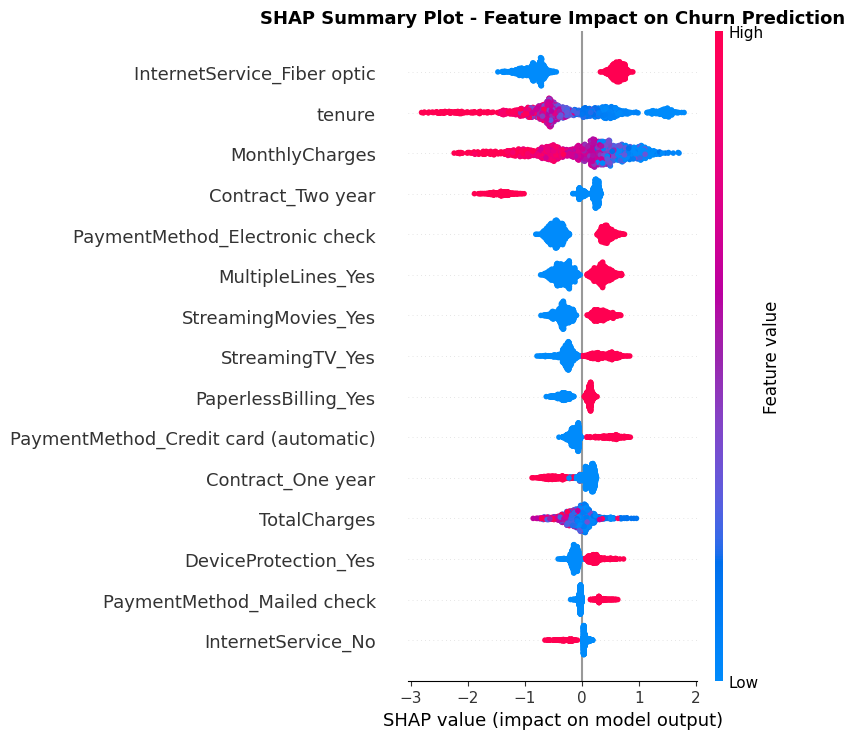

Summary plot saved.


In [18]:
import os
os.makedirs('../reports/figures', exist_ok=True)

plt.figure()
shap.summary_plot(
    shap_values,
    X_test,
    plot_type='dot',       
    max_display=15,        
    show=False
)
plt.title('SHAP Summary Plot - Feature Impact on Churn Prediction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/shap_summary_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Summary plot saved.')

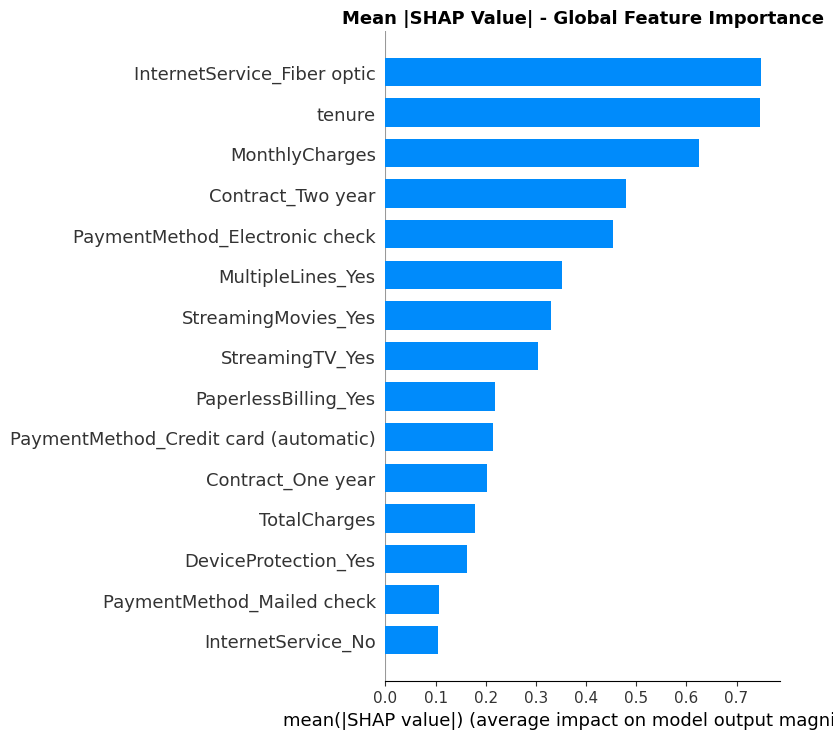

Bar plot saved.


In [19]:
plt.figure()
shap.summary_plot(
    shap_values,
    X_test,
    plot_type='bar',
    max_display=15,
    show=False
)
plt.title('Mean |SHAP Value| - Global Feature Importance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/shap_bar_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Bar plot saved.')

In [20]:
y_prob = model.predict_proba(X_test)[:, 1]

churn_indices = np.argsort(y_prob)[::-1]  # highest first

actual_churners = np.where(y_test.values == 1)[0]
top_churner_idx = [i for i in churn_indices if i in actual_churners][0]

print(f'Selected customer index: {top_churner_idx}')
print(f'Predicted churn probability: {y_prob[top_churner_idx]:.4f}')
print(f'Actual label: {y_test.iloc[top_churner_idx]} (1 = churned)')
print('\nTop features for this customer:')
customer_shap = pd.Series(shap_values[top_churner_idx], index=X_test.columns)
print(customer_shap.sort_values(ascending=False).head(8).round(4))

Selected customer index: 1149
Predicted churn probability: 0.9777
Actual label: 1 (1 = churned)

Top features for this customer:
tenure                            1.4969
InternetService_Fiber optic       0.7186
StreamingTV_Yes                   0.5284
MultipleLines_Yes                 0.4075
StreamingMovies_Yes               0.3763
PaymentMethod_Electronic check    0.3712
Contract_Two year                 0.2599
PaperlessBilling_Yes              0.1920
dtype: float32


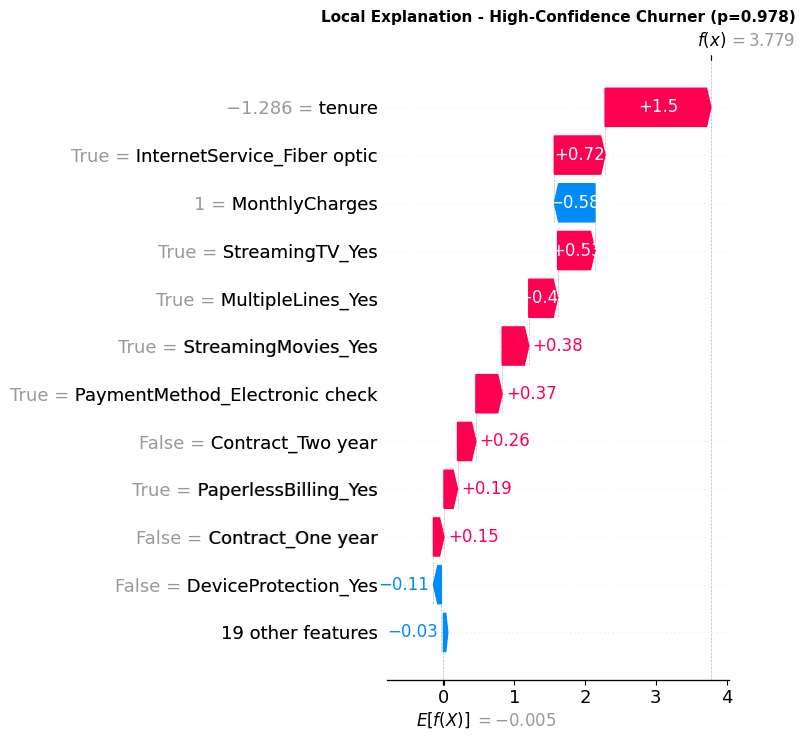

Churner waterfall plot saved.


In [21]:
explanation_churner = shap.Explanation(
    values=shap_values[top_churner_idx],
    base_values=explainer.expected_value,
    data=X_test.iloc[top_churner_idx].values,
    feature_names=X_test.columns.tolist()
)

plt.figure()
shap.plots.waterfall(explanation_churner, max_display=12, show=False)
plt.title(f'Local Explanation - High-Confidence Churner (p={y_prob[top_churner_idx]:.3f})',
          fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/shap_waterfall_churner.png', dpi=150, bbox_inches='tight')
plt.show()
print('Churner waterfall plot saved.')

Selected customer index: 184
Predicted churn probability: 0.0007
Actual label: 0 (0 = did not churn)


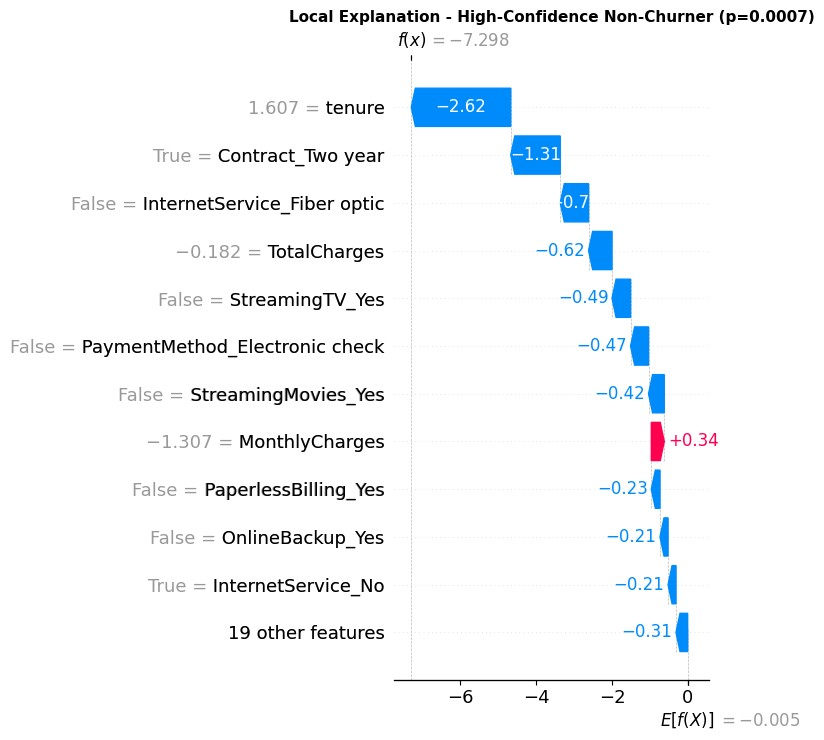

Non-churner waterfall plot saved.


In [22]:
non_churn_indices = np.argsort(y_prob)  
actual_non_churners = np.where(y_test.values == 0)[0]
top_non_churner_idx = [i for i in non_churn_indices if i in actual_non_churners][0]

print(f'Selected customer index: {top_non_churner_idx}')
print(f'Predicted churn probability: {y_prob[top_non_churner_idx]:.4f}')
print(f'Actual label: {y_test.iloc[top_non_churner_idx]} (0 = did not churn)')

explanation_non_churner = shap.Explanation(
    values=shap_values[top_non_churner_idx],
    base_values=explainer.expected_value,
    data=X_test.iloc[top_non_churner_idx].values,
    feature_names=X_test.columns.tolist()
)

plt.figure()
shap.plots.waterfall(explanation_non_churner, max_display=12, show=False)
plt.title(f'Local Explanation - High-Confidence Non-Churner (p={y_prob[top_non_churner_idx]:.4f})',
          fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/shap_waterfall_non_churner.png', dpi=150, bbox_inches='tight')
plt.show()
print('Non-churner waterfall plot saved.')

<Figure size 900x500 with 0 Axes>

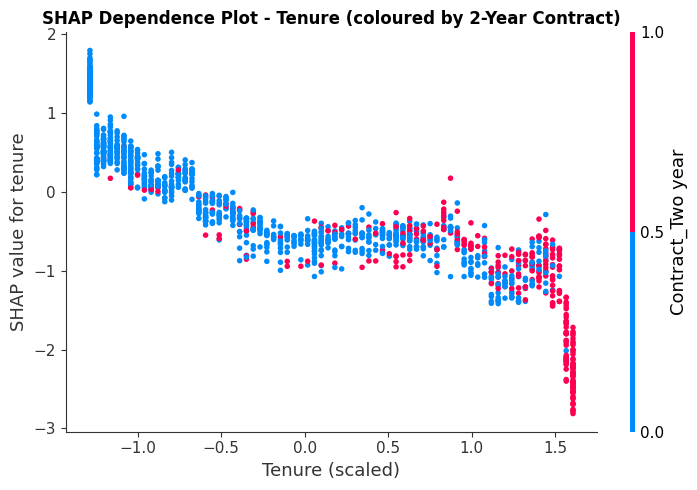

Dependence plot saved.


In [23]:
plt.figure(figsize=(9, 5))
shap.dependence_plot(
    'tenure',
    shap_values,
    X_test,
    interaction_index='Contract_Two year',   
    show=False
)
plt.title('SHAP Dependence Plot - Tenure (coloured by 2-Year Contract)', fontsize=12, fontweight='bold')
plt.xlabel('Tenure (scaled)')
plt.ylabel('SHAP value for tenure')
plt.tight_layout()
plt.savefig('../reports/figures/shap_dependence_tenure.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dependence plot saved.')

<Figure size 900x500 with 0 Axes>

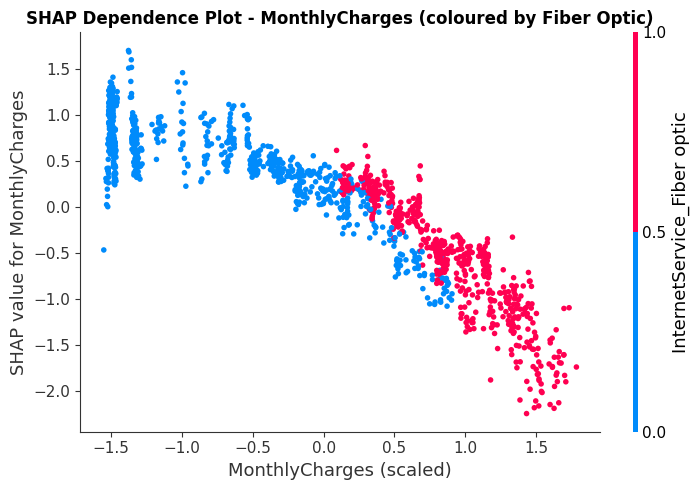

Dependence plot (MonthlyCharges) saved.


In [24]:
plt.figure(figsize=(9, 5))
shap.dependence_plot(
    'MonthlyCharges',
    shap_values,
    X_test,
    interaction_index='InternetService_Fiber optic',
    show=False
)
plt.title('SHAP Dependence Plot - MonthlyCharges (coloured by Fiber Optic)', fontsize=12, fontweight='bold')
plt.xlabel('MonthlyCharges (scaled)')
plt.ylabel('SHAP value for MonthlyCharges')
plt.tight_layout()
plt.savefig('../reports/figures/shap_dependence_monthly_charges.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dependence plot (MonthlyCharges) saved.')

In [25]:
mean_abs_shap = pd.DataFrame({
    'Feature': X_test.columns,
    'Mean |SHAP|': np.abs(shap_values).mean(axis=0)
}).sort_values('Mean |SHAP|', ascending=False).reset_index(drop=True)

mean_abs_shap.index += 1 
print('Top 15 Features by Mean Absolute SHAP Value:')
print('(Higher = more impactful on average across all customers)')
print()
print(mean_abs_shap.head(15).to_string())

mean_abs_shap.to_csv('../reports/shap_feature_importance.csv', index=True)
print('\nFeature importance saved to reports/shap_feature_importance.csv')

Top 15 Features by Mean Absolute SHAP Value:
(Higher = more impactful on average across all customers)

                                  Feature  Mean |SHAP|
1             InternetService_Fiber optic     0.749242
2                                  tenure     0.746859
3                          MonthlyCharges     0.626072
4                       Contract_Two year     0.479224
5          PaymentMethod_Electronic check     0.454231
6                       MultipleLines_Yes     0.351123
7                     StreamingMovies_Yes     0.330622
8                         StreamingTV_Yes     0.303351
9                    PaperlessBilling_Yes     0.218011
10  PaymentMethod_Credit card (automatic)     0.214165
11                      Contract_One year     0.202631
12                           TotalCharges     0.178496
13                   DeviceProtection_Yes     0.163267
14             PaymentMethod_Mailed check     0.105861
15                     InternetService_No     0.103763

Feature importa